# 🌊 BinWaves Duke (Validation)

> **Inputs:**
> - `Kp_coefficients.nc` file saved in the `outputs/` folder, obtained with the `Propagation Notebook`.
> - OPTIONAL: `buoy_buoy_ID_bulk_parameters.pkl`: wave bulk parameters (Hs, Tp, Dp) stored in the `inputs/buoy_data/` folder.
>
>
> **Outputs:**
> - Plots if needed.
> - `Kp_coefficients.nc` file saved in the `outputs/` folder.

### BinWaves Notebooks Overview

This Jupyter Notebook is the first of three in the **BinWaves** modeling workflow, following Cagigal et al., 2024 :

1. `BinWaves_Propagation.ipynb`  
2. `BinWaves_Reconstruction.ipynb`  
3. `BinWaves_Validation.ipynb`

---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk[waves]
  ```
 
---

<details>
<summary><strong>📁 BinWaves_Propagation.ipynb</strong></summary>

This notebook constructs and runs the **library of pre-run cases** for all **monochromatic wave systems**.

</details>

---

<details>
<summary><strong>📁 BinWaves_Reconstruction.ipynb</strong></summary>

This notebook reconstructs **wave conditions** using **offshore directional wave spectra**.

##### Requirements:

- Offshore wave spectrum data (e.g., **CAWCR** or **ERA5** datasets).

- **OPTIONAL 1**: Apply **satellite corrections** to the hindcast spectrum before running BinWaves using the `CalVal` tool in the BlueMath toolkit. An example is provided in the Jupyter Notebook **P00A_CalVal_Carolinas_CAWCR_4469.ipynb**.

- **OPTIONAL 2**: A **Super Point Spectrum** can be also used as input to the hindcast spectrum before running BinWaves. The `SuperPoint` aggregates the energy from a number of points (Wave Spectra) surrounding the study site (Cagigal et al., 2021).  An example is provided in the Jupyter Notebook **Super Point Computation** .

</details>

---

<details open>
<summary><strong>📁 BinWaves_Validation.ipynb</strong></summary>

This notebook performs **validation** using **wave buoy data**, if available.

##### Requirements:

- Wave buoy data in a format compatible with BinWaves (if available).
- Some wave buoy data can be freely downloaded from:  
  🌊 [https://www.ndbc.noaa.gov/](https://www.ndbc.noaa.gov/)

- **NOTE:** You can use the `NDBC_buoy_data.ipynb` notebook to:
  - Download the buoy data.
  - Convert it into the appropriate format for BinWaves.

</details>

In [6]:
import xarray as xr

cawcr_spectrum = xr.open_dataset(
    "inputs/CAWCR_station_4469_spec_satellite_corrected_year_2023.nc"
)
cawcr_spectrum

<xarray.Dataset> Size: 49MB
Dimensions:    (time: 8772, freq: 29, dir: 24)
Coordinates:
  * time       (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00....
    station    int32 4B ...
  * freq       (freq) float32 116B 0.035 0.0385 0.04235 ... 0.4171 0.4589 0.5047
  * dir        (dir) float32 96B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
Data variables:
    efth       (time, freq, dir) float64 49MB ...
    Depth      (time) float32 35kB ...
    Wspeed     (time) float32 35kB ...
    Wdir       (time) float32 35kB ...
    longitude  (time) float32 35kB ...
    latitude   (time) float32 35kB ...

In [7]:
import numpy as np
import pandas as pd

buoys = {
    "44088": (-74.8390, 36.6120),
    "44100": (-75.5930, 36.2580),
    "44086": (-75.4210, 36.0010),
    "44056": (-75.7140, 36.2000),
    "44095": (-75.3300, 35.7500),
    "41120": (-75.2850, 35.2580),
    "41025": (-75.4540, 35.0100),
    "41159": (-76.9440, 34.2110),
    "41110": (-77.7150, 34.1420),
    "41013": (-77.7640, 33.4410),
    "41108": (-78.0160, 33.7210),
}


def find_site_index(kp_coeffs, target_x, target_y, tolerance=1.0):
    """
    Find the site index in kp_coeffs that matches the target coordinates.

    Parameters:
    -----------
    kp_coeffs : xarray.Dataset
        The kp coefficients dataset
    target_x : float
        Target coord_x coordinate
    target_y : float
        Target coord_y coordinate
    tolerance : float
        Tolerance for coordinate

    Returns:
    --------
    int
        The site index that matches the coordinates
    """
    # Get all site coordinates
    site_x = kp_coeffs.coord_x.values
    site_y = kp_coeffs.coord_y.values

    # Calculate distances to all sites
    distances = np.sqrt((site_x - target_x) ** 2 + (site_y - target_y) ** 2)

    # Find the site with minimum distance
    site_index = np.argmin(distances)

    # Check if the closest site is within tolerance
    if distances[site_index] > tolerance:
        print(f"Warning: Closest site is {distances[site_index]:.2f} away")

    return site_index


def load_buoy_data(buoy_id, year=None):
    """
    Load buoy data and return both the wave data and location coordinates.

    Parameters:
    -----------
    buoy_id : str
        The buoy ID (e.g., '44100')
    year : str, optional
        The year to filter data for (default: None)

    Returns:
    --------
    tuple
        (buoy_waves, buoy_location, kp_coeffs)
    """
    # Load buoy data
    buoy_waves = pd.read_pickle(
        f"inputs/buoy_data/buoy_{buoy_id}_bulk_parameters.pkl"
    ).sort_index()
    if year:
        buoy_waves = buoy_waves.loc[year]
    buoy_waves = buoy_waves.dropna(subset=["Hs_Buoy", "Tp_Buoy", "Dir_Buoy"])
    buoy_location = buoys[buoy_id]

    # Load kp coefficients
    kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc")
    site_index = find_site_index(kp_coeffs, buoy_location[0], buoy_location[1])
    kp_coeffs = kp_coeffs.isel(site=[site_index])

    return buoy_waves, buoy_location, kp_coeffs, site_index


buoy_id = "44056"
buoy_waves, buoy_location, kp_coeffs, site_index = load_buoy_data(buoy_id, year="2023")

print(f"Buoy {buoy_id} coordinates:")
print(f"WGS84: {buoy_location[0]}, {buoy_location[1]}")
print("\nSelected kp_coeffs site coordinates:")
print(f"{kp_coeffs.coord_x.values}, {kp_coeffs.coord_y.values}")

Buoy 44056 coordinates:
WGS84: -75.714, 36.2

Selected kp_coeffs site coordinates:
[-75.714], [36.2]


In [8]:
from utils.operations import transform_Offshore_spectrum

model_parameters = pd.read_csv("DUKE_CASES/swan_cases.csv").to_dict(orient="list")

# Load interest spectra
offshore_spectra, offshore_spectra_case = transform_Offshore_spectrum(
    CAWCR_spectrum=cawcr_spectrum,
    subset_parameters=model_parameters,
    available_case_num=kp_coeffs.case_num.values,
    fixed_direction=True,  # True if efth is already in degrees(no radians) and cawcr direction for wavespectra  already corrected (from -> to)'
)
offshore_spectra_case

<xarray.DataArray 'efth' (case_num: 348, time: 8772)> Size: 24MB
array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [1.53917720e-04, 1.53917720e-04, 1.51082963e-04, ...,
        8.13164684e-09, 1.13754900e-08, 1.53403696e-08],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
      shape=(348, 8772))
Coordinates:
  * case_num  (case_num) int64 3kB 0 1 2 3 4 5 6 ... 341 342 343 344 345 346 347
  * time      (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00.0...
    station   int32 4B 133

In [9]:
from bluemath_tk.waves.binwaves import reconstruc_spectra

# Remove duplicates from offshore_spectra_case
_, unique_idx_offshore_case = np.unique(offshore_spectra_case.time, return_index=True)
offshore_spectra_case = offshore_spectra_case.isel(time=unique_idx_offshore_case)

# Remove duplicates from offshore_spectra_case
_, unique_idx_offshore = np.unique(offshore_spectra.time, return_index=True)
offshore_spectra = offshore_spectra.isel(time=unique_idx_offshore)

# Make sure buoy_waves has unique indices
buoy_waves = buoy_waves[~buoy_waves.index.duplicated(keep="first")]

reconstructed_onshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra_case.sel(time=buoy_waves.index, method="nearest"),
    kp_coeffs=kp_coeffs,
)
reconstructed_onshore_spectra

<xarray.Dataset> Size: 47MB
Dimensions:  (site: 1, freq: 29, dir: 24, time: 8397)
Coordinates:
  * site     (site) int64 8B 80
  * freq     (freq) float64 232B 0.035 0.0385 0.0423 ... 0.4171 0.4589 0.5047
  * dir      (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    lat      float64 8B 0.0
    lon      float64 8B 0.0
    coord_x  (site) float64 8B -75.71
    coord_y  (site) float64 8B 36.2
  * time     (time) datetime64[ns] 67kB 2023-01-01 ... 2023-12-17T23:00:00.00...
    station  int32 4B 133
Data variables:
    kps      (time, site, freq, dir) float64 47MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

Time series plot saved as: outputs/Figures/timeseries_Wave Validation 44056.png
Scatter plot saved as: outputs/Figures/scatter_Wave Validation 44056.png


(<Figure size 2000x1000 with 3 Axes>,
 array([<Axes: xlabel='time', ylabel='Hs [m]'>,
        <Axes: xlabel='time', ylabel='T [s] - tp'>,
        <Axes: ylabel='Dir [°] - dm'>], dtype=object),
 <Figure size 1500x500 with 3 Axes>,
 array([<Axes: xlabel='Hs - Buoy [m]', ylabel='Hs - BinWaves [m]'>,
        <Axes: xlabel='Tp - Buoy [s]', ylabel='Tp - BinWaves [s]'>,
        <Axes: xlabel='Dir - Buoy [°]', ylabel='Dir - BinWaves [°]'>],
       dtype=object))

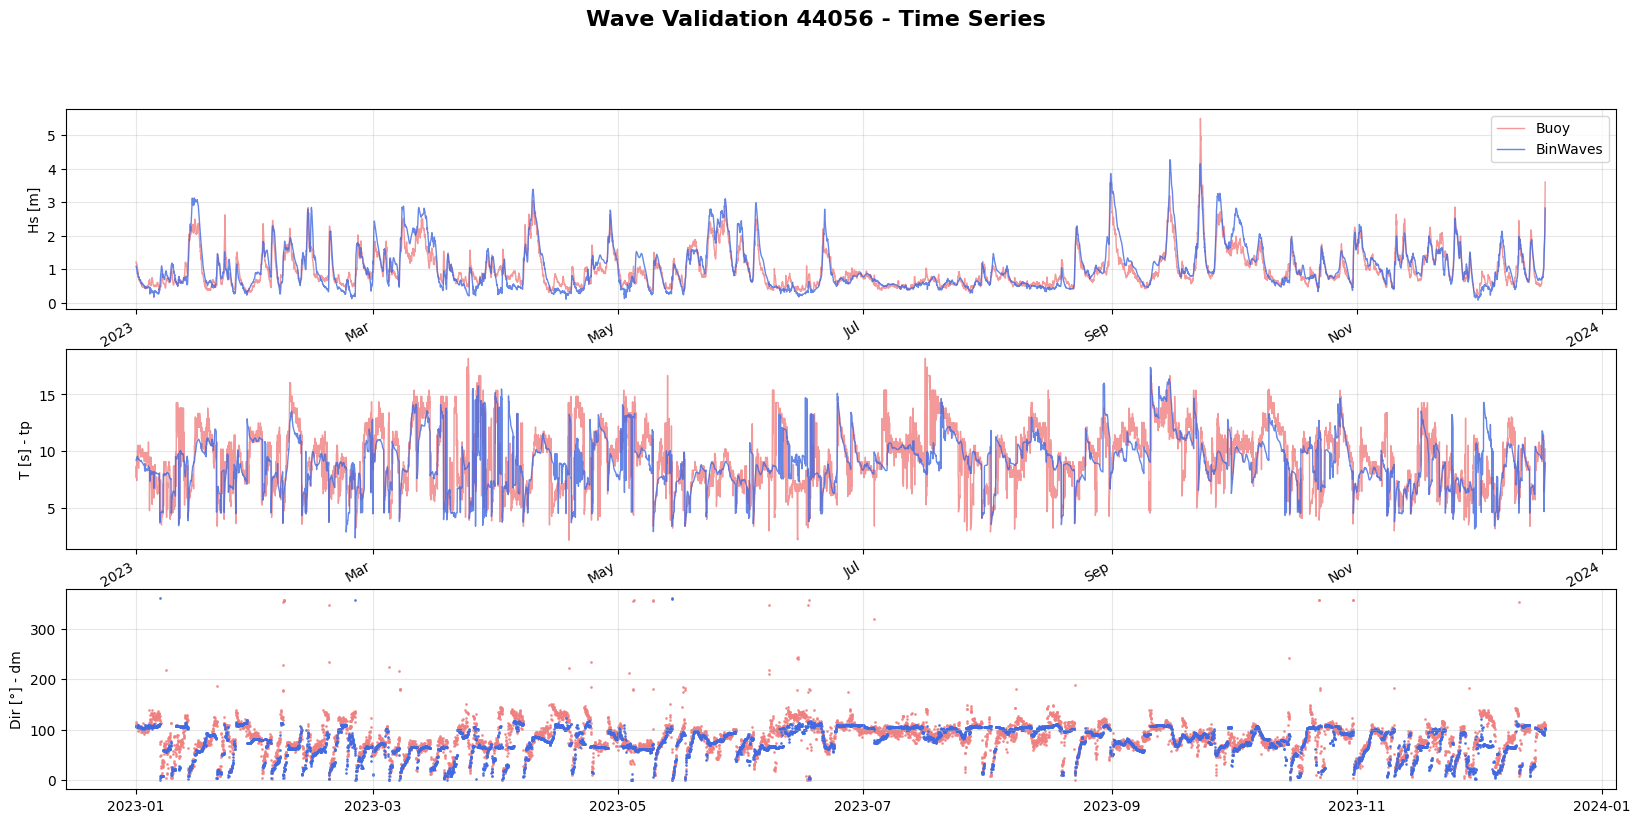

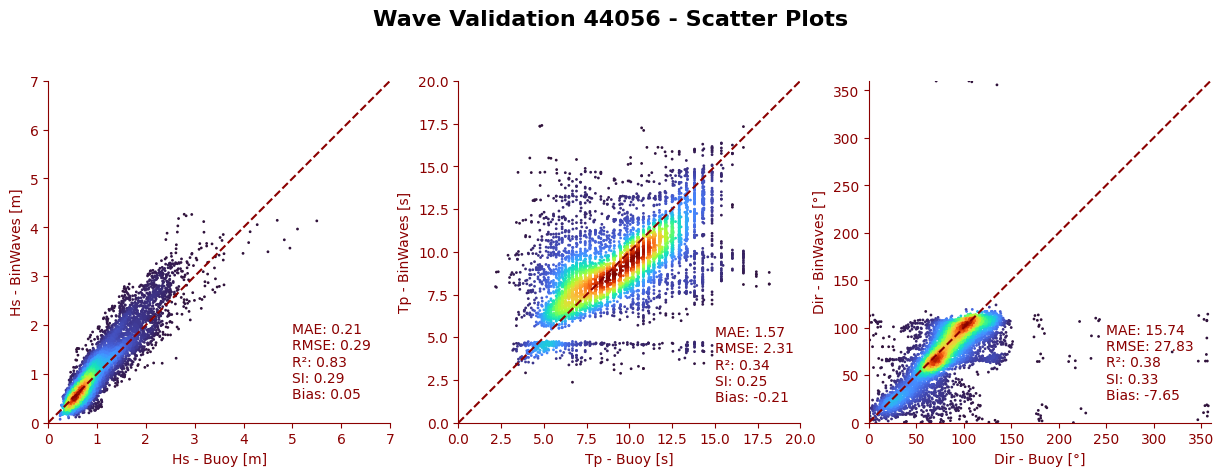

In [10]:
from utils.plotting import plot_wave_series

plot_wave_series(
    buoy_data=buoy_waves,
    binwaves_data=reconstructed_onshore_spectra.sel(
        time=buoy_waves.index, method="nearest"
    )
    .rename({"kps": "efth"})
    .squeeze()
    .spec,
    offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
    times=buoy_waves.index.values,
    save_plots=True,
    save_path="outputs/Figures/",
    title_prefix="Wave Validation " + buoy_id,
)